# Project - Airline AI Assistant

We'll now bring together what we've learned to make an AI Customer Support assistant for an Airline

In [2]:
# imports

import os
import json
from dotenv import load_dotenv
from openai import OpenAI
import gradio as gr
import sqlite3

In [3]:
# Initialization

load_dotenv(override=True)

openai_api_key = os.getenv('OPENAI_API_KEY')
if openai_api_key:
    print(f"OpenAI API Key exists and begins {openai_api_key[:8]}")
else:
    print("OpenAI API Key not set")
    
MODEL = "gpt-5-mini"
CHAT_MODEL = "openai/gpt-5-mini"
IMAGE_MODEL = "openai/gpt-5-image-mini"
AUDIO_MODEL = "openai/gpt-5-audio"
openai = OpenAI(
    base_url="https://openrouter.ai/api/v1", 
    api_key=openai_api_key,
)
client = openai
DB = "prices.db"

OpenAI API Key exists and begins sk-or-v1


In [4]:
system_message = """
You are a helpful assistant for an Airline called FlightAI.
Give short, courteous answers, no more than 1 sentence.
Always be accurate. If you don't know the answer, say so.
"""

In [5]:
def get_ticket_price(city):
    print(f"DATABASE TOOL CALLED: Getting price for {city}", flush=True)
    with sqlite3.connect(DB) as conn:
        cursor = conn.cursor()
        cursor.execute('SELECT price FROM prices WHERE city = ?', (city.lower(),))
        result = cursor.fetchone()
        return f"Ticket price to {city} is ${result[0]}" if result else "No price data available for this city"

In [8]:
get_ticket_price("Paris")

DATABASE TOOL CALLED: Getting price for Paris


OperationalError: no such table: prices

In [7]:
price_function = {
    "name": "get_ticket_price",
    "description": "Get the price of a return ticket to the destination city.",
    "parameters": {
        "type": "object",
        "properties": {
            "destination_city": {
                "type": "string",
                "description": "The city that the customer wants to travel to",
            },
        },
        "required": ["destination_city"],
        "additionalProperties": False
    }
}
tools = [{"type": "function", "function": price_function}]
tools   

[{'type': 'function',
  'function': {'name': 'get_ticket_price',
   'description': 'Get the price of a return ticket to the destination city.',
   'parameters': {'type': 'object',
    'properties': {'destination_city': {'type': 'string',
      'description': 'The city that the customer wants to travel to'}},
    'required': ['destination_city'],
    'additionalProperties': False}}}]

In [ ]:

def chat(message, history):
    history = [{"role": h["role"], "content": h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = openai.chat.completions.create(model=MODEL, messages=messages)
    return response.choices[0].message.content

gr.ChatInterface(fn=chat, type="messages").launch()

In [10]:
def chat(message, history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)

    while response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        responses = handle_tool_calls(message)
        messages.append(message)
        messages.extend(responses)
        response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)
    
    return response.choices[0].message.content

In [11]:
def handle_tool_calls(message):
    responses = []
    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_ticket_price":
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get('destination_city')
            price_details = get_ticket_price(city)
            responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    return responses

In [ ]:
gr.ChatInterface(fn=chat, type="messages").launch()

## A bit more about what Gradio actually does:

1. Gradio constructs a frontend Svelte app based on our Python description of the UI
2. Gradio starts a server built upon the Starlette web framework listening on a free port that serves this React app
3. Gradio creates backend routes for our callbacks, like chat(), which calls our functions

And of course when Gradio generates the frontend app, it ensures that the the Submit button calls the right backend route.

That's it!

It's simple, and it has a result that feels magical.

# Let's go multi-modal!!

We can use DALL-E-3, the image generation model behind GPT-4o, to make us some images

Let's put this in a function called artist.

### Price alert: each time I generate an image it costs about 4 cents - don't go crazy with images!

In [15]:
import base64
from PIL import Image
from io import BytesIO

# Change this to an active model ID cost 4 cents per run
IMAGE_MODEL = "google/gemini-2.5-flash-image"

def artist(city):
    response = client.chat.completions.create(
        model=IMAGE_MODEL,
        messages=[
            {
                "role": "user",
                "content": f"An image representing a vacation in {city}, showing tourist spots and everything unique about {city}, in a vibrant pop-art style"
            }
        ],
        # Must include this for Gemini image generation
        extra_body={
            "modalities": ["text", "image"]
        }
    )

    if response.choices[0].message.images:
        for image in response.choices[0].message.images:
            image_url = image["image_url"]["url"]  # Base64 data URL
            base64_data = image_url.split(",")[1]
            return Image.open(BytesIO(base64.b64decode(base64_data)))
 

# Comment when using the artist function
    #return Image.open("/home/andres/Programs/PycharmProjects/ai_bootcamp/llm_engineering/week2/community-contributions/andresr27/NewYork1.png")

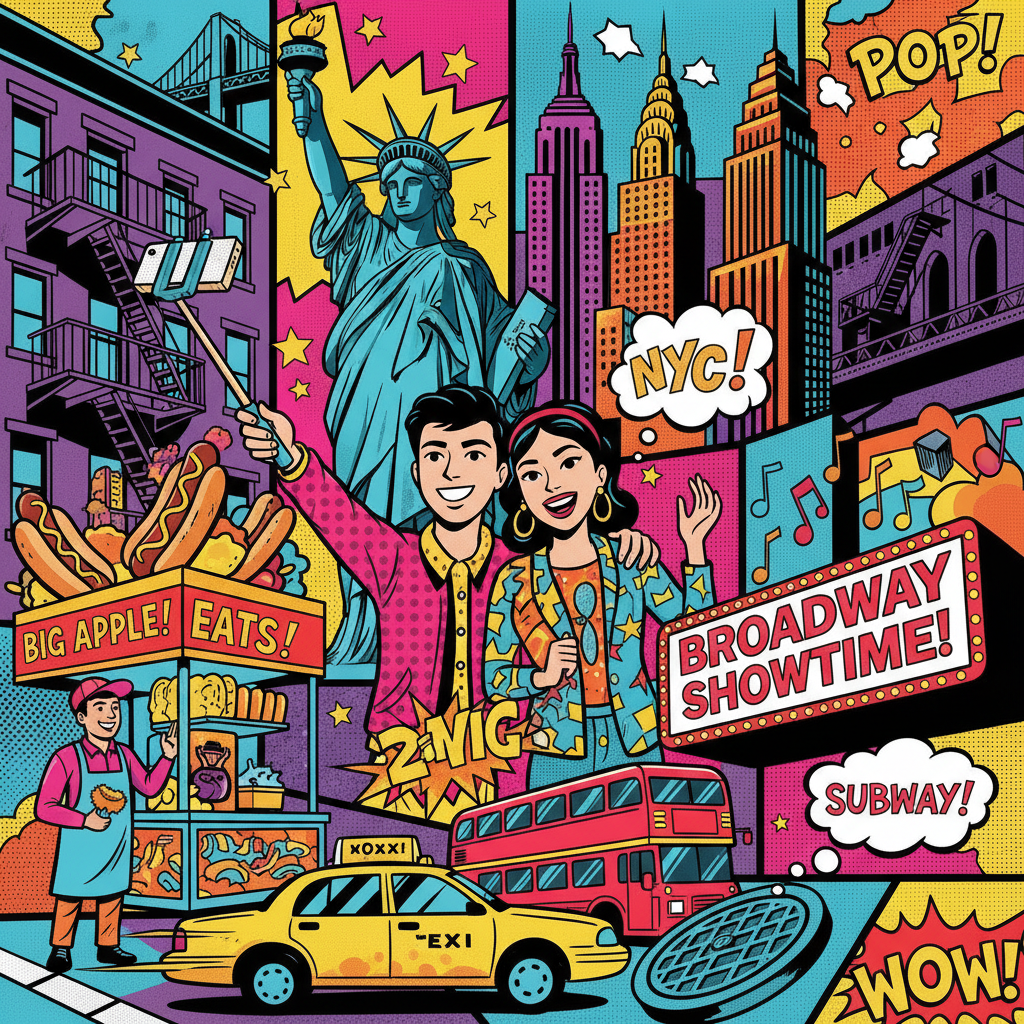

In [ ]:
image = artist("New York City")
display(image)

In [16]:
import base64
import numpy as np
from pvspeaker import PvSpeaker    

def play_audio(full_audio_base64):
    # 1. Decode
    audio_bytes = base64.b64decode(full_audio_base64)

    # 2. Padding Fix
    if len(audio_bytes) % 2 != 0:
        audio_bytes += b'\x00'

    # 3. Convert to list of integers
    pcm = np.frombuffer(audio_bytes, dtype=np.int16).tolist()

    # 4. Initialize with OpenAI's 24kHz standard
    
    speaker = PvSpeaker(sample_rate=24000, bits_per_sample=16)
    
    #print(f"Playing {len(pcm)} samples...")
    
    try:
        speaker.start()
        # Use write to feed the buffer
        speaker.write(pcm)
        # Use flush to wait until the audio hardware finishes playing
        speaker.flush() 
    finally:
        speaker.stop()
        speaker.delete()
    
    print("Playback finished.")

def talker(message):

    stream = openai.chat.completions.create(
      model="openai/gpt-audio-mini",
      modalities=["text", "audio"],
      audio={"voice": "alloy", "format": "pcm16"},
      stream=True, 
      messages=[
          {
              "role": "user",
              "content": message  
          }
      ]
    )
     
    # 2. Iterate through the stream to collect audio chunks
    full_audio_base64 = ""
    for chunk in stream:
        if hasattr(chunk.choices[0].delta, 'audio') and chunk.choices[0].delta.audio:
            if 'data' in chunk.choices[0].delta.audio:
                # Append the raw base64 chunks
                full_audio_base64 += chunk.choices[0].delta.audio['data']

    if not full_audio_base64:
        return None

    # 2. Convert base64 to NumPy array (Gradio's preferred format)
    audio_bytes = base64.b64decode(full_audio_base64)
    
    # Padding fix for pcm16 byte alignment
    if len(audio_bytes) % 2 != 0:
        audio_bytes += b'\x00'
        
    audio_data = np.frombuffer(audio_bytes, dtype=np.int16)
    
    # 3. Return (Sample Rate, Data) to Gradio
    # OpenAI pcm16 is standard 24000Hz
    return (24000, audio_data)
        

In [14]:
voice = talker("Hello, how are you?")
#play_audio(voice)

## Let's bring this home:

1. A multi-modal AI assistant with image and audio generation
2. Tool callling with database lookup
3. A step towards an Agentic workflow


In [ ]:
def chat(history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history
    response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)
    cities = []
    image = artist("New York City")

    while response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        responses, cities = handle_tool_calls_and_return_cities(message)
        messages.append(message)
        messages.extend(responses)
        response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)

    reply = response.choices[0].message.content
    history += [{"role":"assistant", "content":reply}]

    voice = talker(reply)

    if cities:
        image = artist(cities[0])
    
    return history, voice, image


DATABASE TOOL CALLED: Getting price for London


In [ ]:
def handle_tool_calls_and_return_cities(message):
    responses = []
    cities = []
    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_ticket_price":
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get('destination_city')
            cities.append(city)
            price_details = get_ticket_price(city)
            responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    return responses, cities

## The 3 types of Gradio UI

`gr.Interface` is for standard, simple UIs

`gr.ChatInterface` is for standard ChatBot UIs

`gr.Blocks` is for custom UIs where you control the components and the callbacks

In [ ]:
# Callbacks (along with the chat() function above)

def put_message_in_chatbot(message, history):
        return "", history + [{"role":"user", "content":message}]

# UI definition

with gr.Blocks() as ui:
    with gr.Row():
        chatbot = gr.Chatbot(height=500, type="messages")
        image_output = gr.Image(height=500, interactive=False)
    with gr.Row():
        audio_output = gr.Audio(label="AI Voice", streaming=True, autoplay=True)
    with gr.Row():
        message = gr.Textbox(label="Chat with our AI Assistant:")

# Hooking up events to callbacks
    #input_text.submit(stream_audio_response, inputs=input_text, outputs=output_audio)
    message.submit(put_message_in_chatbot, inputs=[message, chatbot], outputs=[message, chatbot]).then(
        chat, inputs=chatbot, outputs=[chatbot, audio_output, image_output]
    )

ui.launch(inbrowser=True, auth=("ed", "bananas"))

* Running on local URL:  http://127.0.0.1:7869
* To create a public link, set `share=True` in `launch()`.


Opening in existing browser session.


# Exercises and Business Applications

Add in more tools - perhaps to simulate actually booking a flight. A student has done this and provided their example in the community contributions folder.

Next: take this and apply it to your business. Make a multi-modal AI assistant with tools that could carry out an activity for your work. A customer support assistant? New employee onboarding assistant? So many possibilities! Also, see the week2 end of week Exercise in the separate Notebook.

<table style="margin: 0; text-align: left;">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/thankyou.jpg" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#090;">I have a special request for you</h2>
            <span style="color:#090;">
                My editor tells me that it makes a HUGE difference when students rate this course on Udemy - it's one of the main ways that Udemy decides whether to show it to others. If you're able to take a minute to rate this, I'd be so very grateful! And regardless - always please reach out to me at ed@edwarddonner.com if I can help at any point.
            </span>
        </td>
    </tr>
</table>